In [3]:
from qiskit import QuantumCircuit as QC
from qiskit_aer import AerSimulator as AS
from qiskit.visualization import plot_histogram as ph
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager as gp
import matplotlib.pyplot as plt

#IBM Runtime Specific 
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService

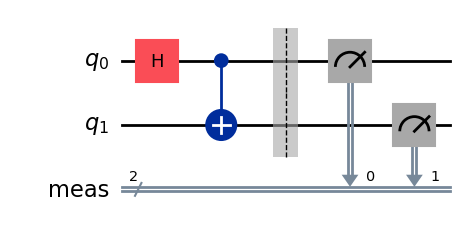

In [6]:
bell = QC(2)
bell.h(0)
bell.cx(0,1)

bell.measure_all()
bell.draw("mpl")


In [14]:
def run_circuit_and_get_counts(circuit, backend, shots=1000):
    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1
    )

    isa_circuit = pm.run(circuit)

    sampler = Sampler(mode=backend)

    # Wrap the circuit in a list
    job = sampler.run([isa_circuit], shots=shots)

    result = job.result()

    return result[0].data.meas.get_counts()

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="b1tmMEruSdXs4FQ1dGnZ122gxzaIN-pVvYYEP4OzJX3T",
    overwrite=True,
    set_as_default=True,
)

In [12]:
service = QiskitRuntimeService(channel='ibm_quantum_platform')

service = QiskitRuntimeService()

backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-07-03 18:28:51,981: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.__init__:WARNING:2026-07-03 18:28:54,564: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:20

ibm_marrakesh


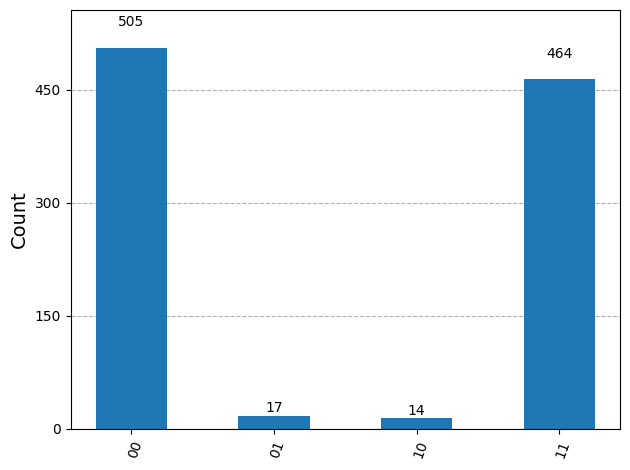

In [15]:
counts = run_circuit_and_get_counts(bell,backend,shots=1000)
plot_histogram(counts)